In [1]:
import xarray as xr
import matplotlib.pyplot as plt
import glob
import numpy as np
from glob import glob
from itertools import compress
from matplotlib.dates import DateFormatter
import matplotlib.dates as mdates
import pandas as pd

In [2]:
files_in = glob("/data/project/ARM_Summer_School_2026/data/modeling/dpscream/scream_dpxx_LASSO_SGP_*.fullfield.AVERAGE.nhours_x1.*.nc")
ds_dp_scream = xr.open_mfdataset(files_in, combine='nested', concat_dim = 'date')
ds_dp_scream = ds_dp_scream.assign_coords(time=ds_dp_scream.time - pd.Timedelta(hours=6))

ERROR 1: PROJ: proj_create_from_database: Open of /opt/conda/share/proj failed


/opt/conda/lib/python3.11/site-packages/dask/array/reductions.py:324: RuntimeWarning: All-NaN slice encountered
  return np.nanmax(x_chunk, axis=axis, keepdims=keepdims)


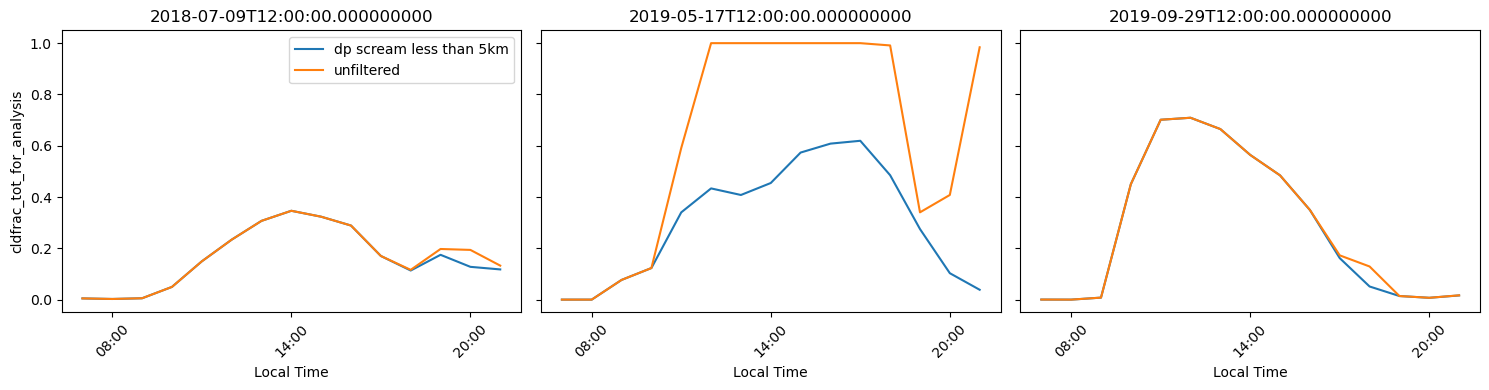

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

for i, ax in enumerate(axes):
  ds_dp_scream['cldfrac_tot_for_analysis'].where(ds_dp_scream['z_mid'] < 5000).max(dim='lev').mean('ncol').isel(date=i).plot(
      ax=ax, label="dp scream less than 5km"
  )
  ds_dp_scream['cldfrac_tot_for_analysis'].max(dim='lev').mean('ncol').isel(date=i).plot(
      ax=ax, label="unfiltered"
    )
  
  date_label =  np.unique(ds_dp_scream.isel(date= i).time_bnds.values)[0] 
  ax.set_title(date_label)

  ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
  ax.xaxis.set_major_locator(mdates.HourLocator(interval=6))
  plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)
  ax.set_xlabel("Local Time")
  if i > 0:
      ax.set_ylabel("")

axes[0].legend()
plt.tight_layout()
plt.show()

In [97]:
# x = np.unique(ds_dp_scream.lon.values)   # 10 values: 2500, 7500, ..., 47500 m
# y = np.unique(ds_dp_scream.lat.values)   # same

# cf_colmax = ds_dp_scream['cldfrac_tot_for_analysis'].max(dim='lev')   # (time, ncol)

# cf_scream = xr.DataArray(
#   cf_colmax.values.reshape(ds_dp_scream.sizes['time'], len(y), len(x)),
#   dims=['time', 'y', 'x'],
#   coords={
#       'time': ds_dp_scream.time,
#       'y': y,
#       'x': x,
#   },
#   attrs={'units': '1', 'long_name': 'Column-max total cloud fraction'},
# )

# cf_scream.isel(time = 8).plot()

In [74]:
def progress_bar(current, total, width=40, fill="#", empty="-", show_percent=True):
    """
    Return an ASCII progress bar string.

    Parameters
    ----------
    current : int or float
        Current progress value.
    total : int or float
        Total value corresponding to 100%.
    width : int
        Width of the bar in characters.
    fill : str
        Character used for completed portion.
    empty : str
        Character used for remaining portion.
    show_percent : bool
        Whether to append percentage text.

    Returns
    -------
    str
        Formatted progress bar.
    """
    if total <= 0:
        raise ValueError("total must be > 0")

    fraction = max(0.0, min(1.0, current / total))
    filled = int(round(fraction * width))

    bar = fill * filled + empty * (width - filled)

    if show_percent:
        percent = fraction * 100
        return f"[{bar}] {percent:6.2f}%"

    return f"[{bar}]"

/tmp/ipykernel_2743/3594974941.py:13: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.subplots()


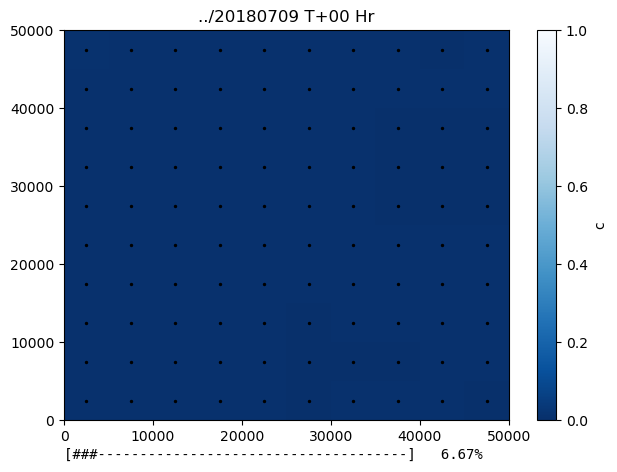

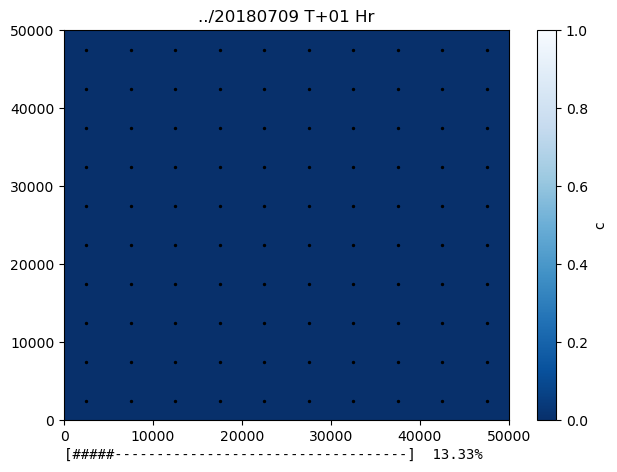

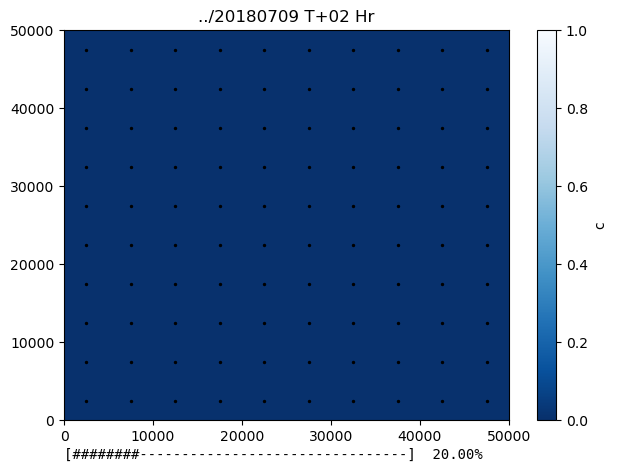

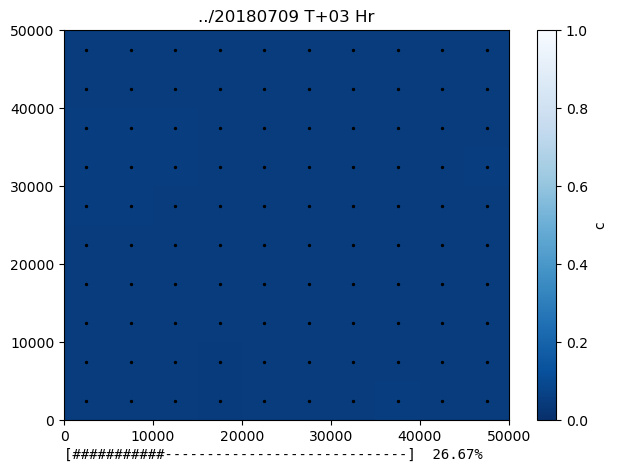

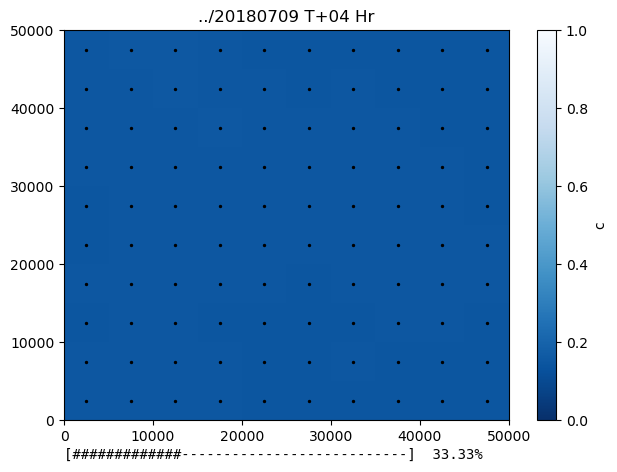

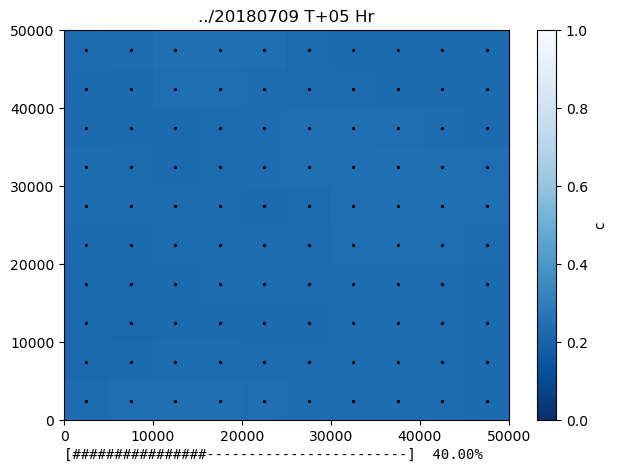

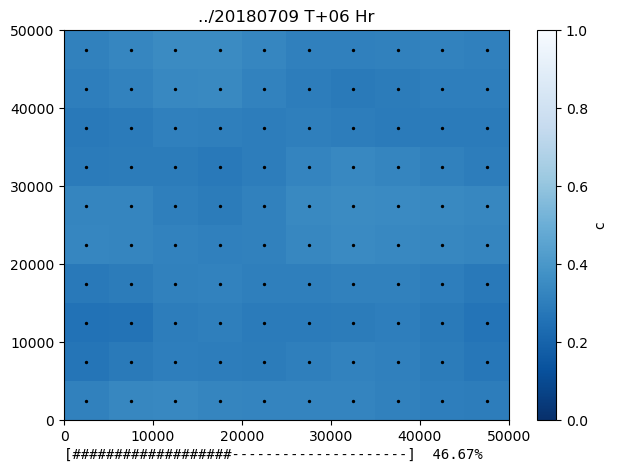

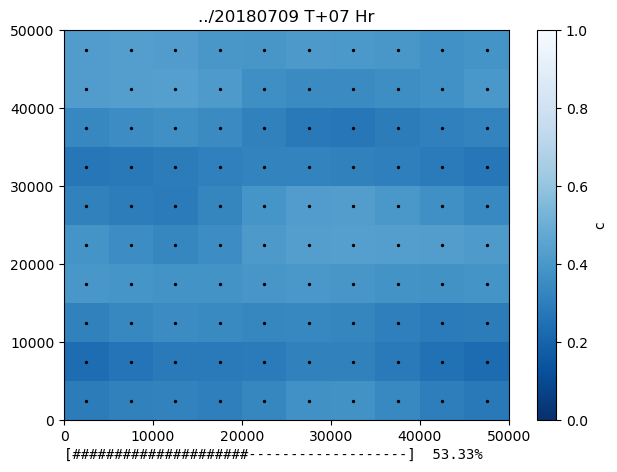

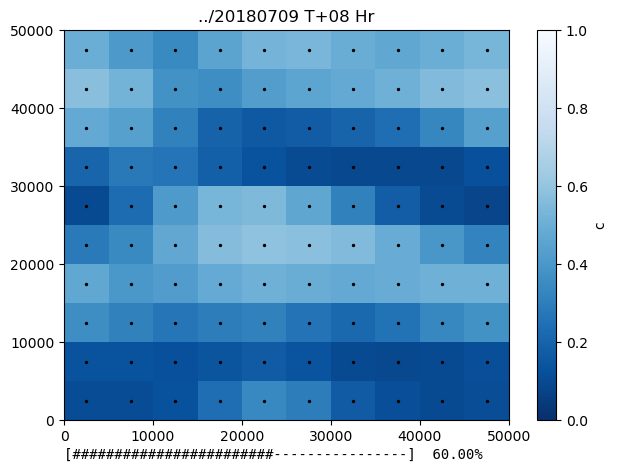

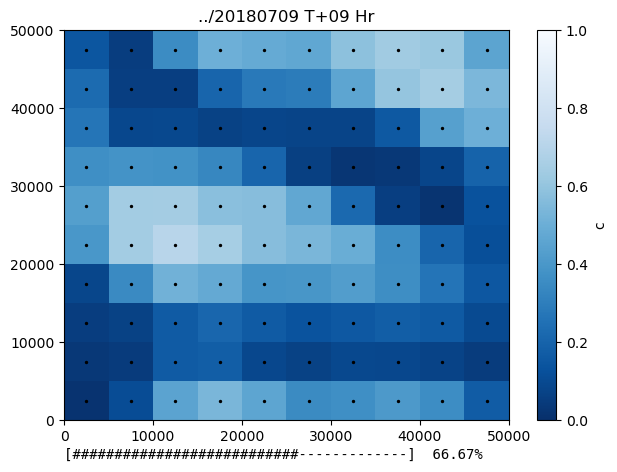

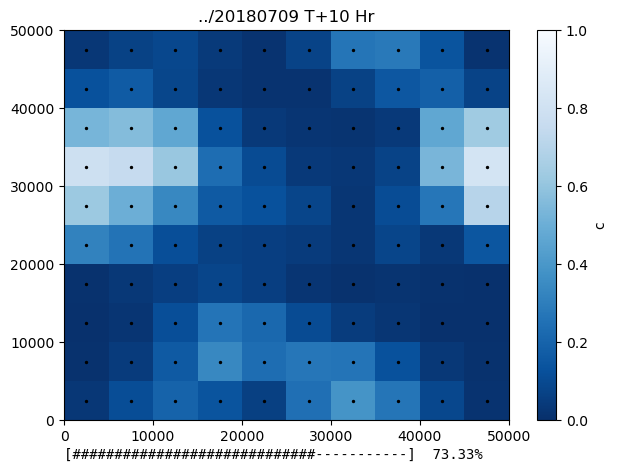

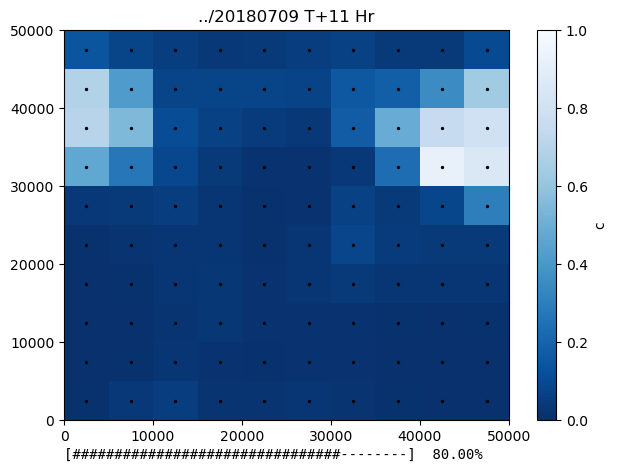

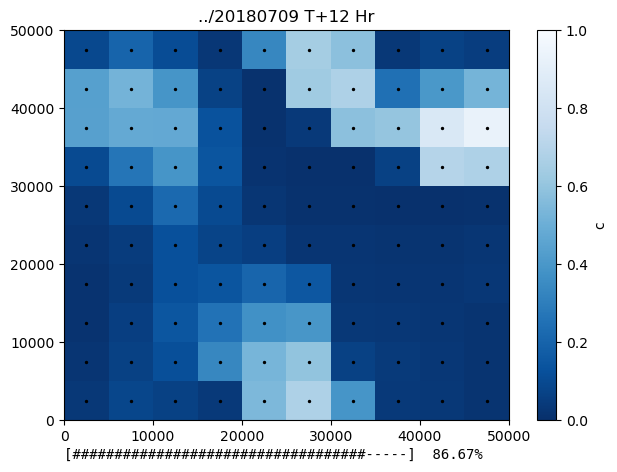

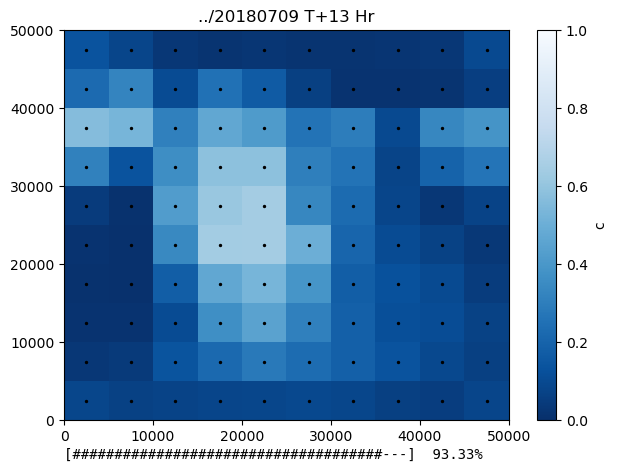

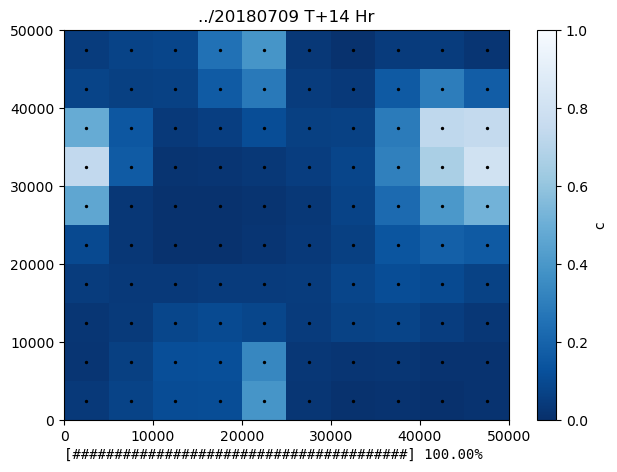

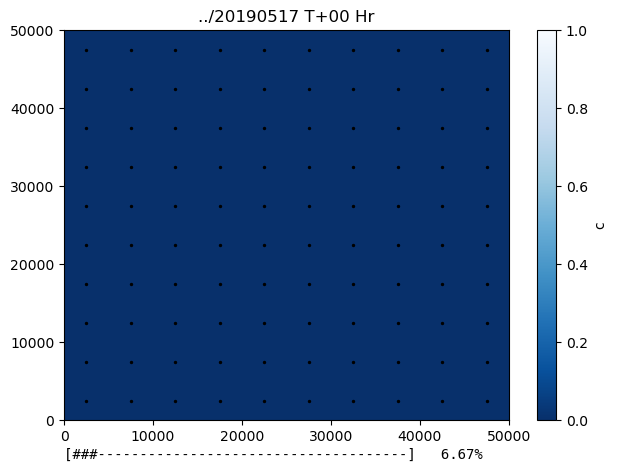

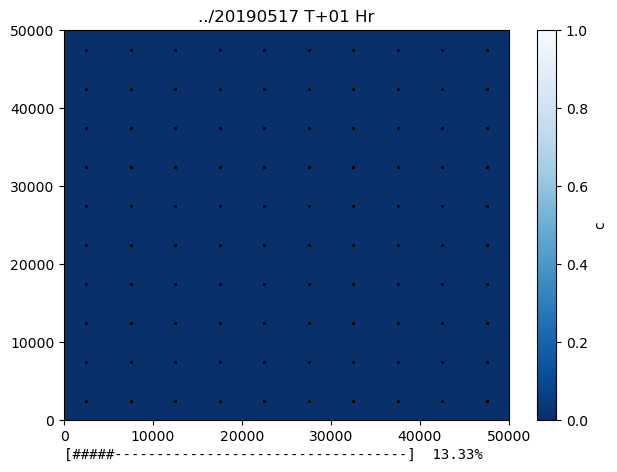

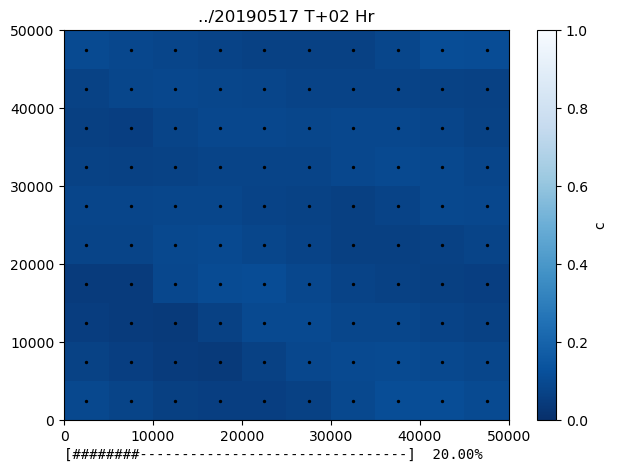

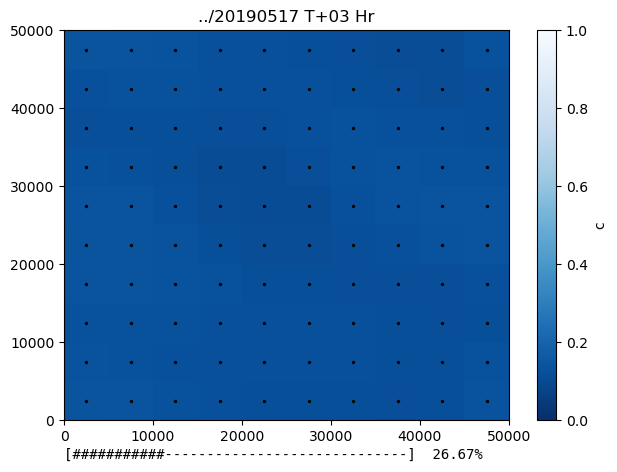

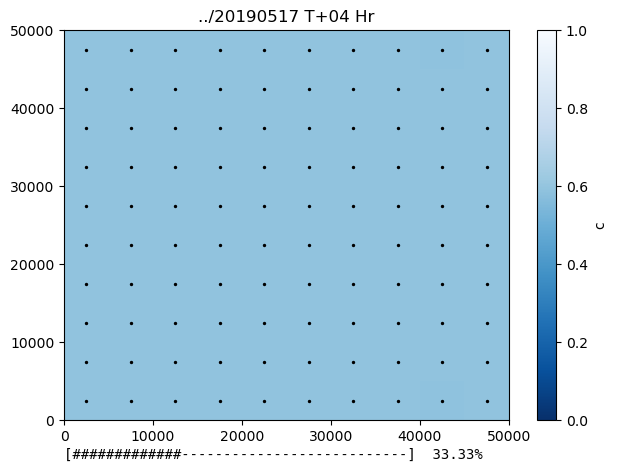

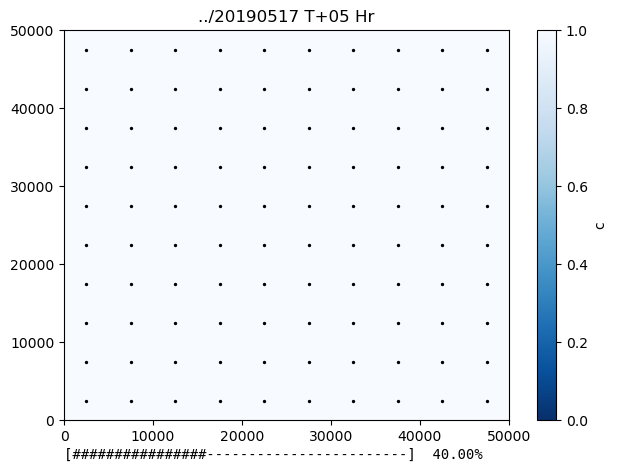

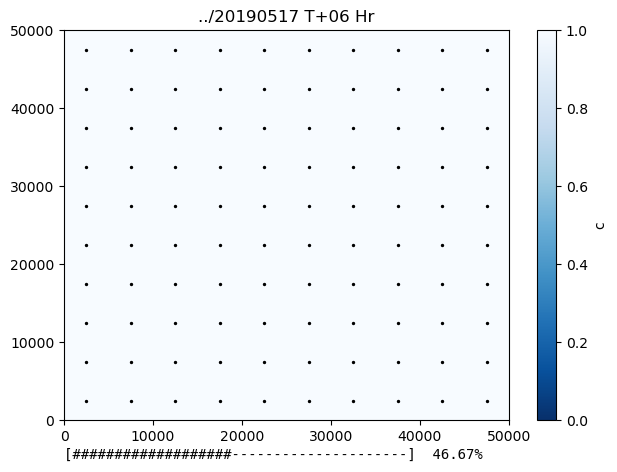

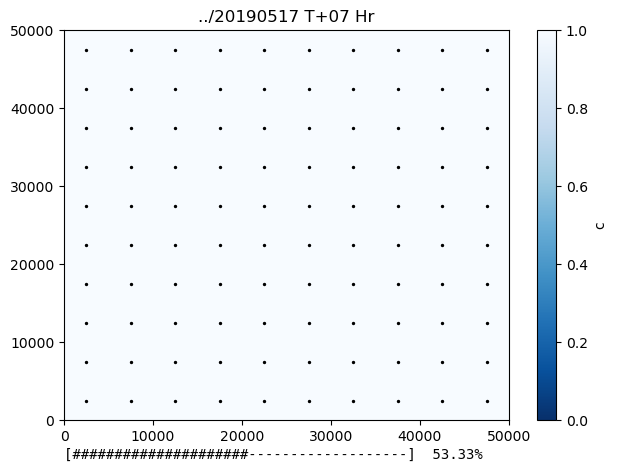

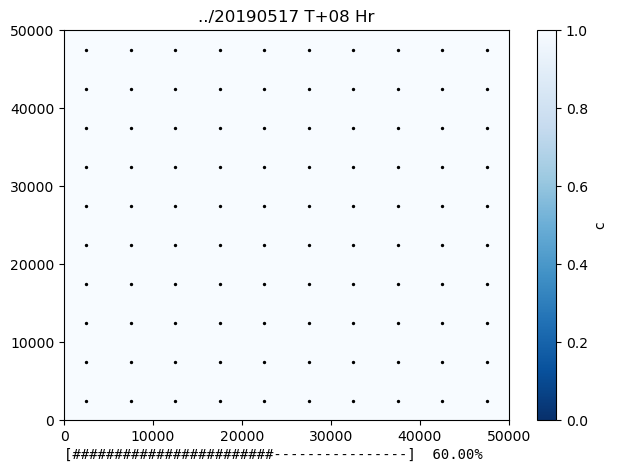

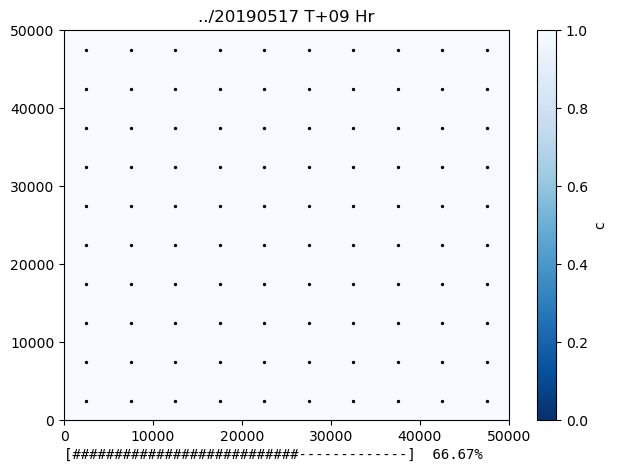

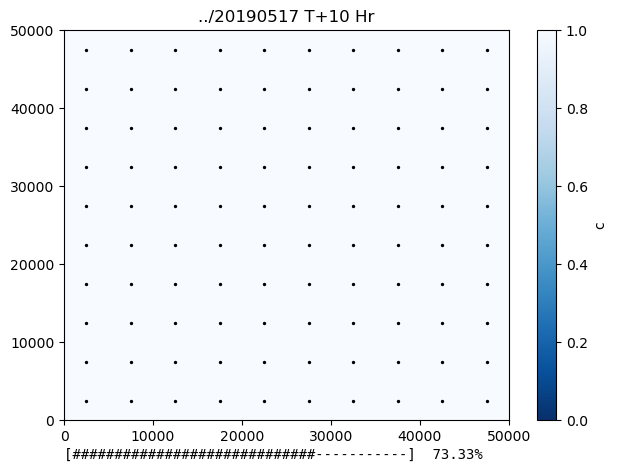

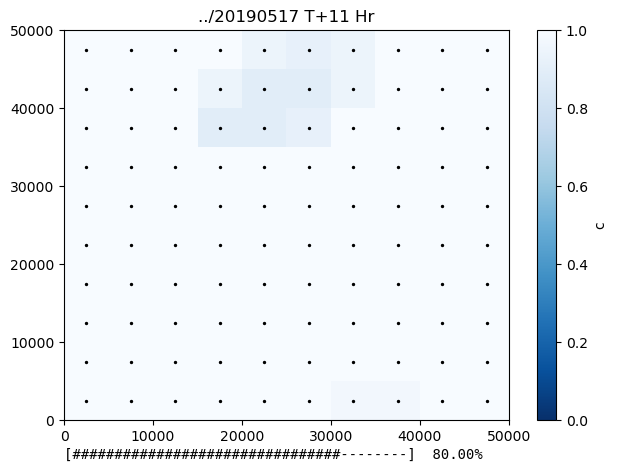

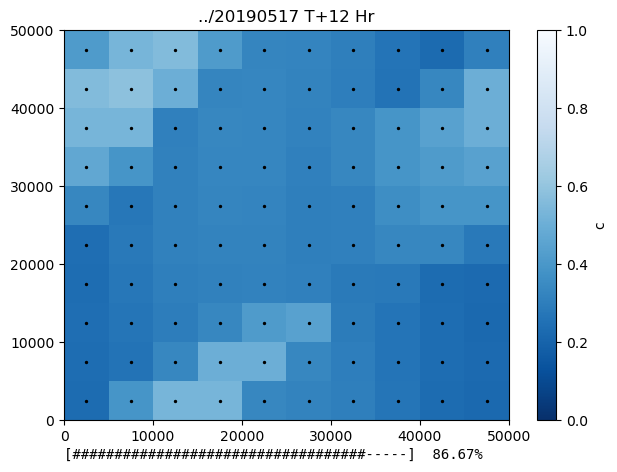

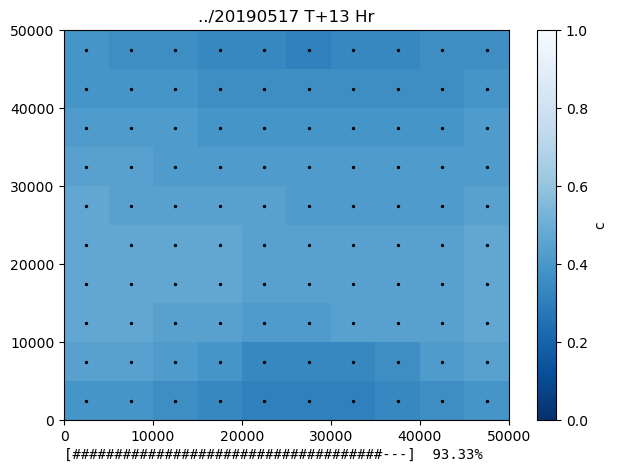

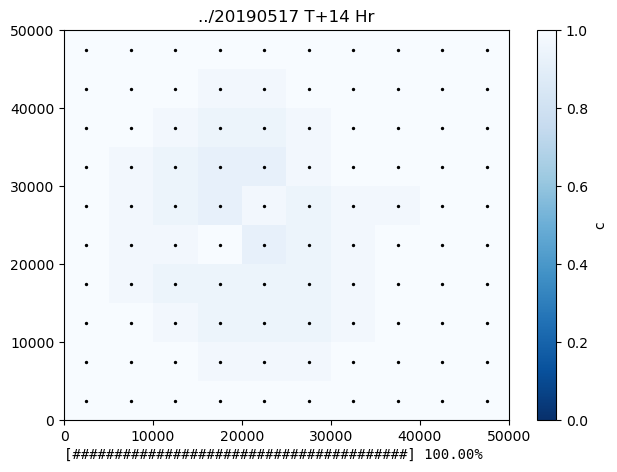

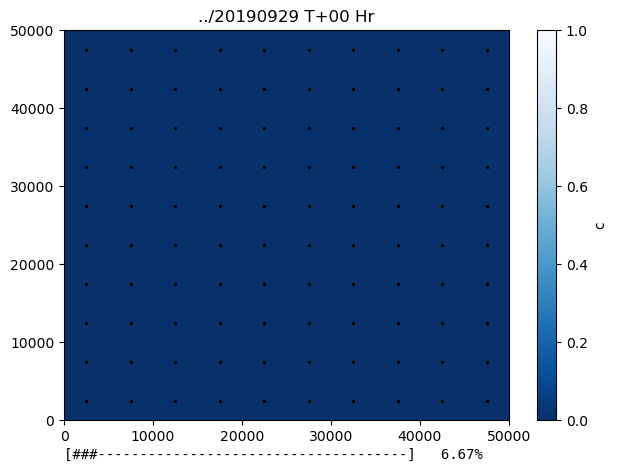

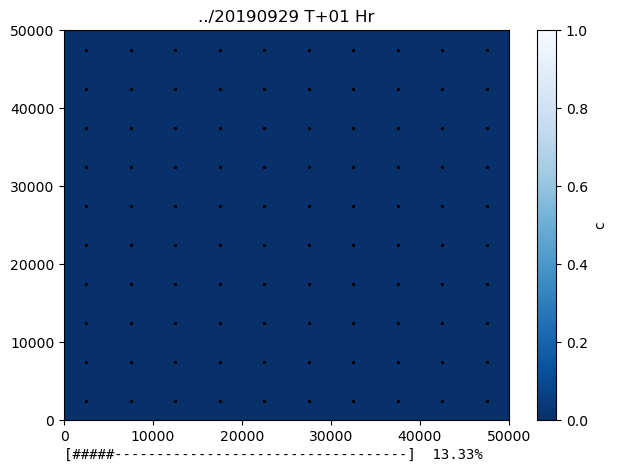

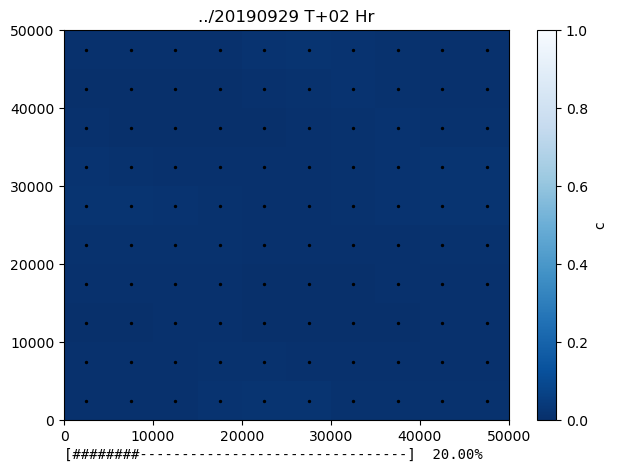

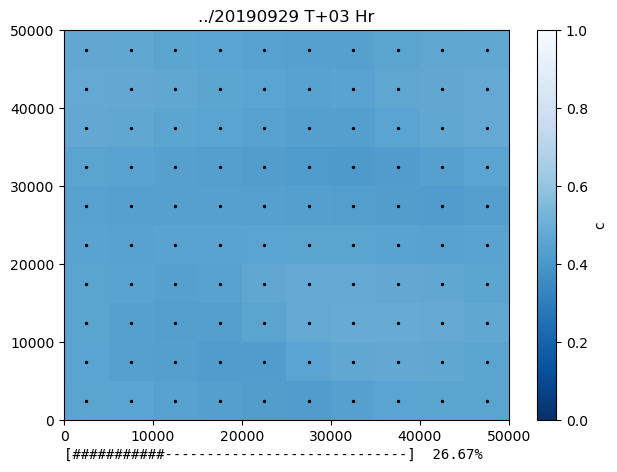

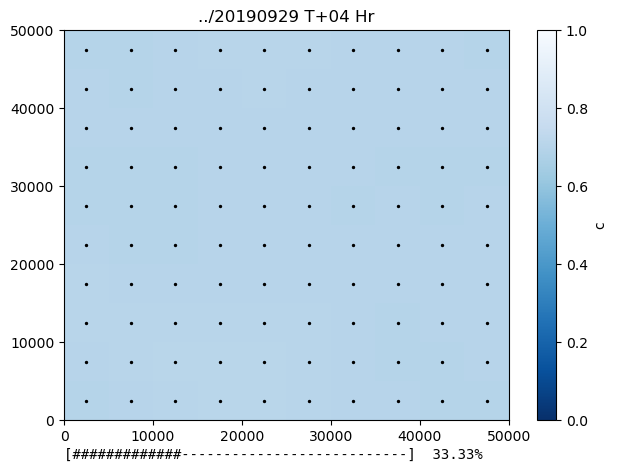

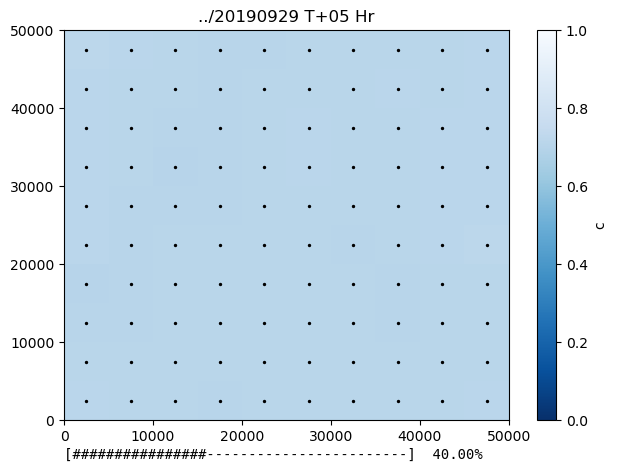

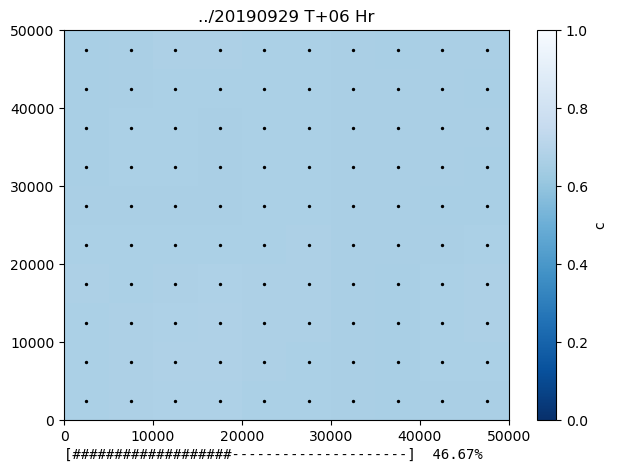

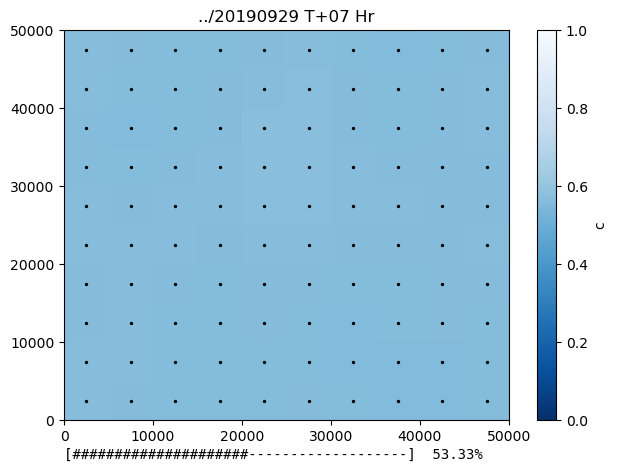

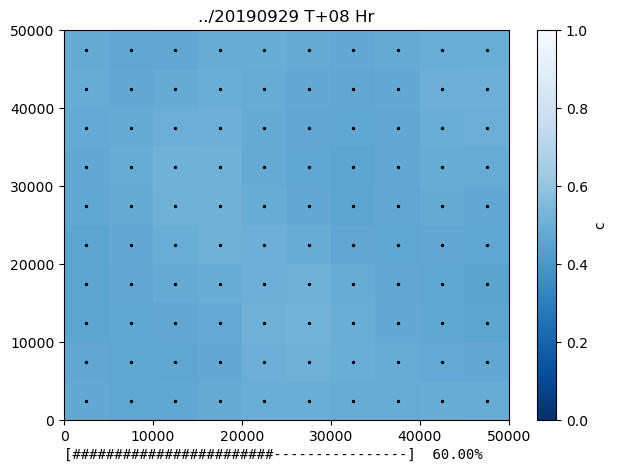

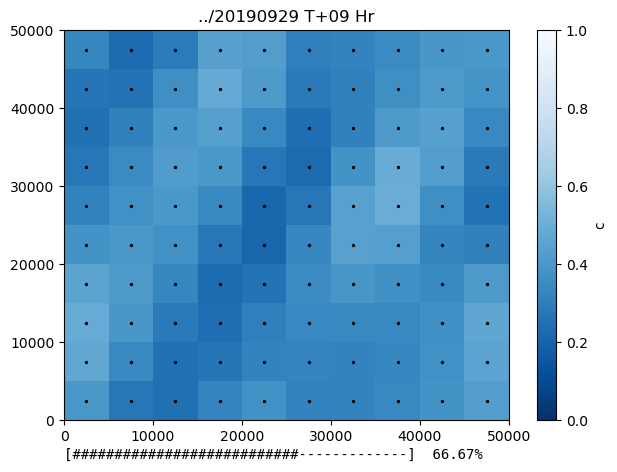

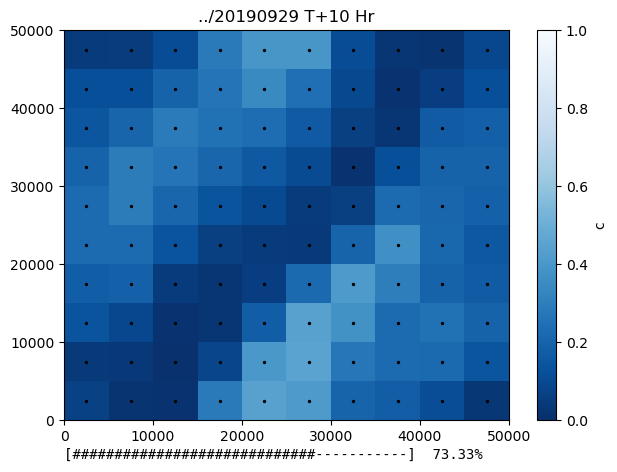

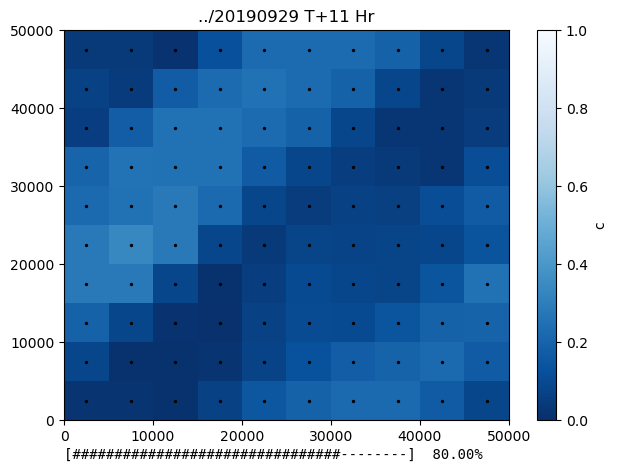

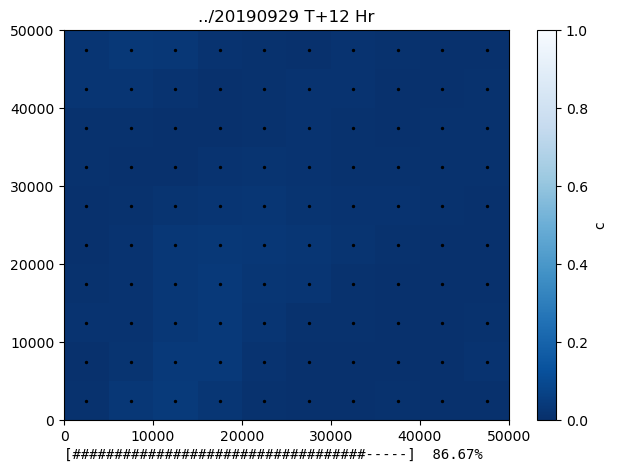

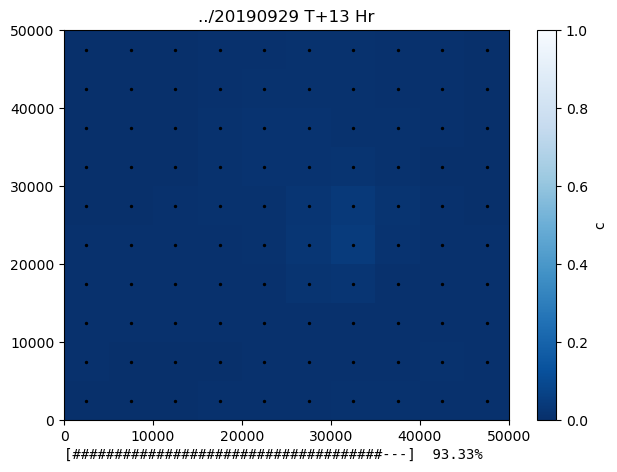

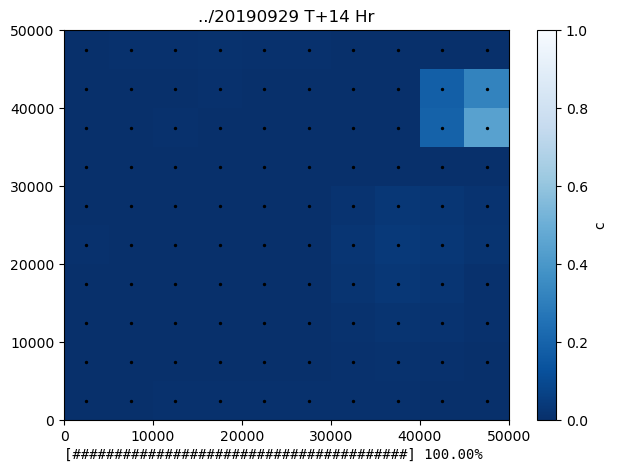

In [95]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import griddata

CASE_DATES = [20180709,
              20190517,
              20190929]

for date in range(3):
# for date in [0]:
    for time in range(15):
    # for time in [0]:
        plt.subplots()
        x=cf_colmax.isel(date=date).isel(time=date*15+time).lon.values,
        y=cf_colmax.isel(date=date).isel(time=date*15+time).lat.values,
        c=cf_colmax.isel(date=date).isel(time=date*15+time),
        
        # target regular grid
        xi = np.linspace(2500,47500, 10)
        yi = np.linspace(2500,47500, 10)
        
        Xi, Yi = np.meshgrid(xi, yi)
        
        # interpolate
        Ci = griddata(
            (x[0], y[0]),
            c[0],
            (Xi, Yi),
            method='linear'
        )
        plt.pcolormesh(Xi, Yi, Ci,
                      vmin = 0, vmax = 1, cmap = 'Blues_r')
        plt.colorbar(label='c')
        plt.scatter(x, y, s=2, c='k')  # optional: show original points
        plt.title(f"../{CASE_DATES[date]} T+{time:02} Hr")
        plt.text(0,-5000,progress_bar(time+1, 15),fontfamily='monospace')
        plt.tight_layout()
        plt.savefig(f"../test-{CASE_DATES[date]}-T+{time:02}.png")
        
        # plt.show()

# GIFs

In [98]:
import imageio.v2 as imageio
from pathlib import Path

# directory containing images
img_dir = Path("../")

for date in range(3):

    # collect and sort images
    images = sorted(img_dir.glob(f"test-{CASE_DATES[date]}*.png"))
    
    with imageio.get_writer(f"dpscream-cloud-cover-animation-{CASE_DATES[date]}.gif", mode="I", duration=0.2, loop=0) as writer:
        for img in images:
            frame = imageio.imread(img)
            writer.append_data(frame)